# Telco Customer Churn Analysis

This notebook analyzes customer churn data, performs data cleaning, exploratory data analysis (EDA), and identifies potential factors contributing to churn.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)


## Loading Data

In [2]:
filepath = os.path.join("datasets", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(filepath)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning
We convert `TotalCharges` to numeric and drop rows with missing values. We also check for duplicates.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
print('Rows before drop:', df.shape)
df.dropna(subset=['TotalCharges'], inplace=True)
print('Rows after drop:', df.shape)

Rows before drop: (7043, 21)
Rows after drop: (7032, 21)


In [6]:
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)
We begin with demographic and service-related variables to examine churn patterns.

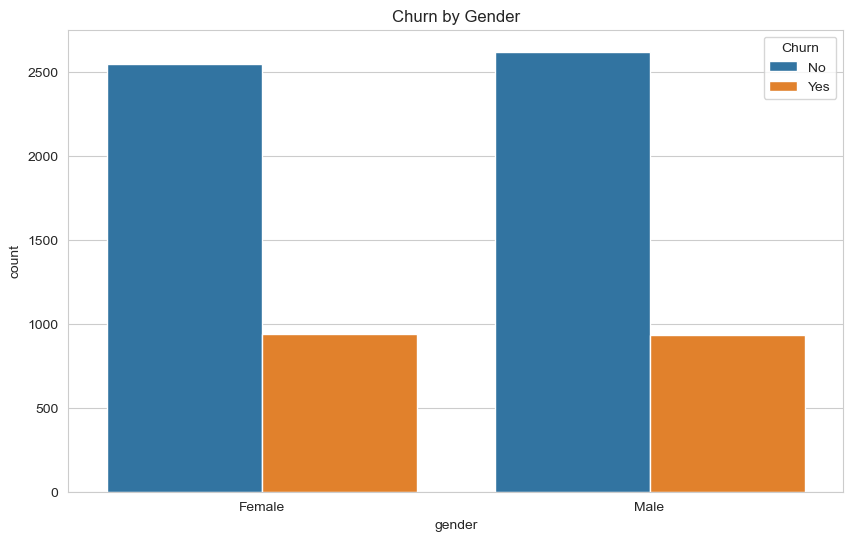

In [7]:
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Churn by Gender')
plt.show()


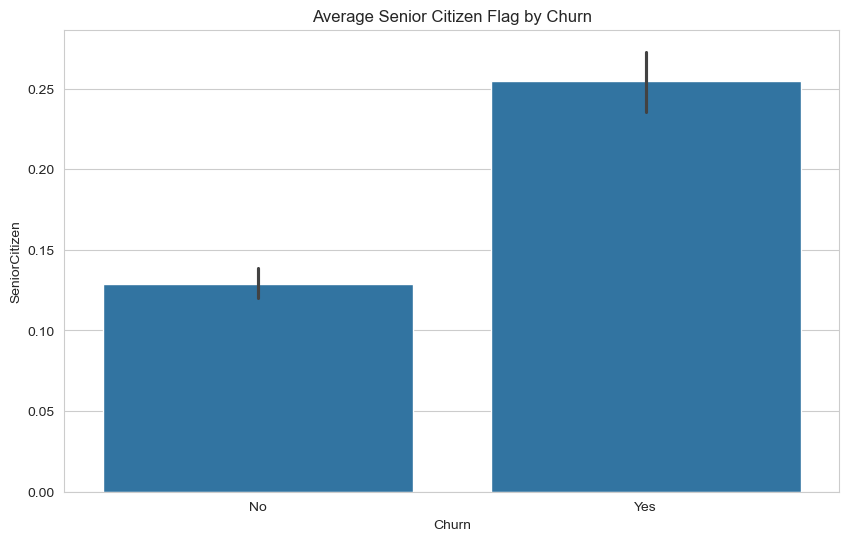

In [8]:
df['SeniorCitizen'] = pd.to_numeric(df['SeniorCitizen'], errors='coerce')
sns.barplot(data=df, x='Churn', y='SeniorCitizen')
plt.title('Average Senior Citizen Flag by Churn')
plt.show()


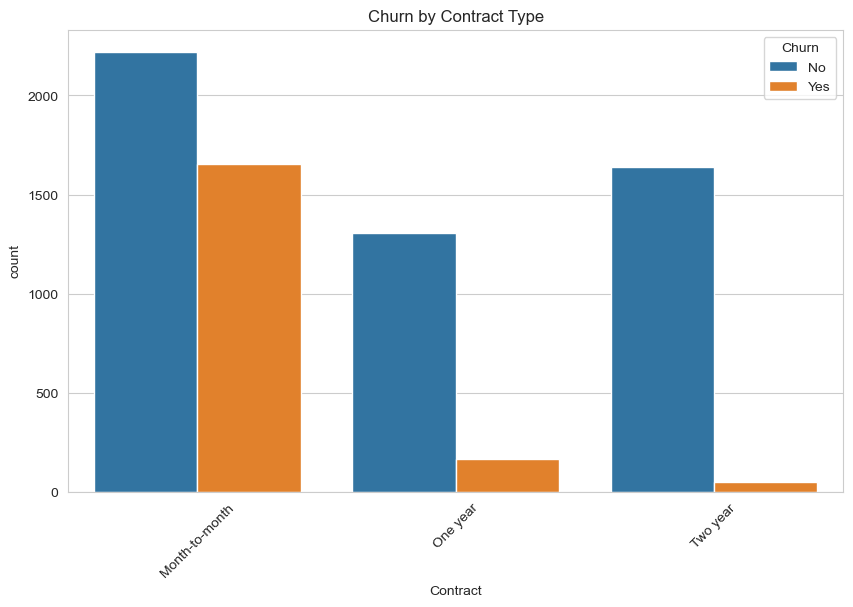

In [9]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xticks(rotation=45)
plt.show()


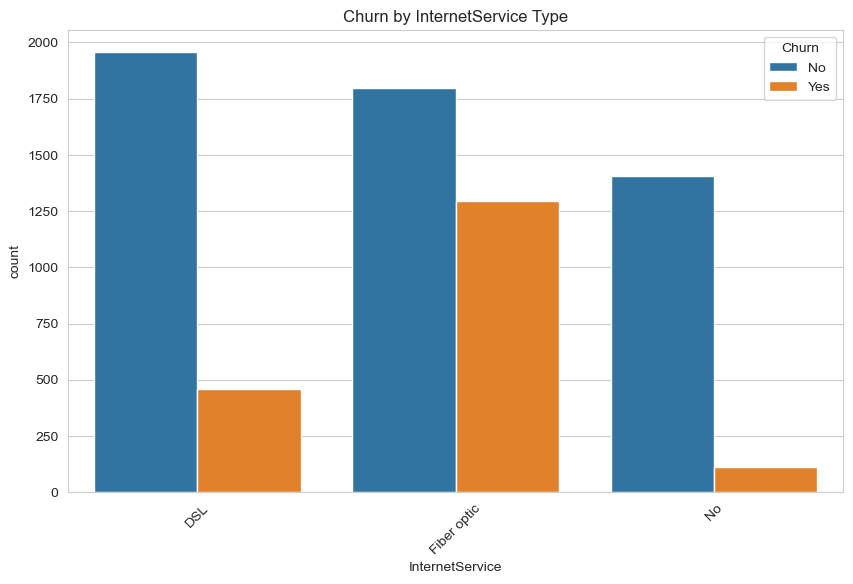

In [10]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by InternetService Type')
plt.xticks(rotation=45)
plt.show()


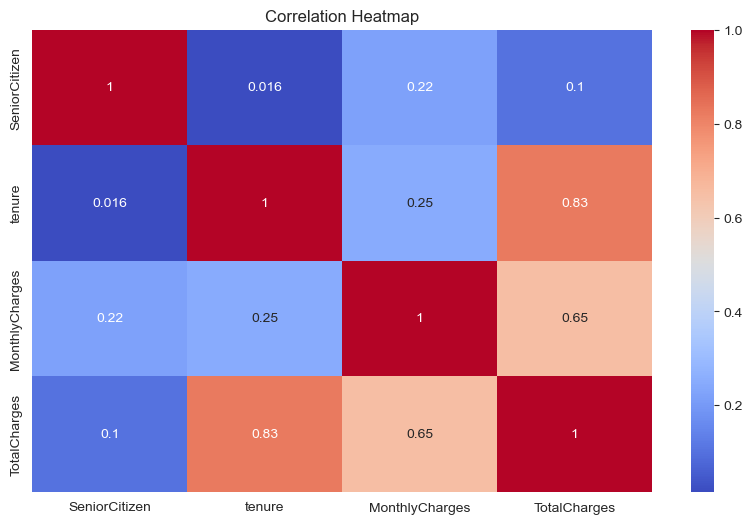

In [11]:
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## Conclusion
This initial analysis highlights several variables potentially related to churn, such as contract type and total charges. Further modeling or hypothesis testing could be performed to confirm these relationships.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### preprocessing

In [13]:
df.drop('customerID',axis=1,inplace=True)

### scaling numirc

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[['TotalCharges','MonthlyCharges','tenure']]=scaler.fit_transform(df[['TotalCharges','MonthlyCharges','tenure']])


In [15]:
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


### encoding

In [16]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
cols=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
cols2=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols2:
    df[col] = df[col].map({'Yes': 2, 'No': 1,"No internet service":0})
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 2, 'No': 1,'No phone service':0})
df['InternetService'] = df['InternetService'].map({'DSL': 2, 'No': 0,'Fiber optic':1})
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1,'Two year':2})
df['PaymentMethod'] = df['PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1,'Bank transfer (automatic)':2,'Credit card (automatic)':3})


In [17]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [18]:
from imblearn.over_sampling import SMOTEN
somt=SMOTEN(random_state=42)
X_res, y_res = somt.fit_resample(X, y)

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_res, y_res, test_size=0.30, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=150,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [21]:
from sklearn.metrics import classification_report
y_pred=model.predict(X_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1563
           1       0.85      0.85      0.85      1535

    accuracy                           0.85      3098
   macro avg       0.85      0.85      0.85      3098
weighted avg       0.85      0.85      0.85      3098



In [24]:
# Save the model (run this in your notebook or script)
import pickle
from sklearn.ensemble import RandomForestClassifier

# Assuming `model` is your trained RandomForestClassifier
model_path = "model/random_forest_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)